In [2]:
from google.colab import files

uploaded = files.upload()


Saving employee_survey_data.csv to employee_survey_data (1).csv


In [3]:
import pandas as pd

filename = next(iter(uploaded))
df = pd.read_csv(filename)

df.head()

,Employee_ID,Department,Location,Tenure_Years,Engagement_Score,Manager_Support,Work_Life_Balance,Career_Growth,Recommend_Company,Survey_Completed
0,E001,Sales,Los Gatos,10,5,4,4,3,4,No
1,E002,Finance,Los Gatos,6,4,3,4,5,2,No
2,E003,Sales,New York,9,2,3,3,5,5,Yes
3,E004,Finance,Remote,7,4,5,2,5,2,No
4,E005,HR,Los Gatos,5,4,4,2,2,5,Yes


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Employee_ID        40 non-null     object
 1   Department         40 non-null     object
 2   Location           40 non-null     object
 3   Tenure_Years       40 non-null     int64 
 4   Engagement_Score   40 non-null     int64 
 5   Manager_Support    40 non-null     int64 
 6   Work_Life_Balance  40 non-null     int64 
 7   Career_Growth      40 non-null     int64 
 8   Recommend_Company  40 non-null     int64 
 9   Survey_Completed   40 non-null     object
dtypes: int64(6), object(4)
memory usage: 3.3+ KB


In [5]:
df.isnull().sum()

,0
Employee_ID,0
Department,0
Location,0
Tenure_Years,0
Engagement_Score,0
Manager_Support,0
Work_Life_Balance,0
Career_Growth,0
Recommend_Company,0
Survey_Completed,0


In [6]:
df.describe()

,Tenure_Years,Engagement_Score,Manager_Support,Work_Life_Balance,Career_Growth,Recommend_Company
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,4.950000,3.500000,3.475000,3.325000,3.825000,3.400000
std,2.773039,1.132277,1.176424,1.095152,1.059451,1.236206
min,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,2.750000,3.000000,2.000000,2.000000,3.000000,2.000000
50%,4.000000,3.000000,3.000000,3.000000,4.000000,4.000000
75%,7.000000,5.000000,5.000000,4.000000,5.000000,4.250000
max,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
completion_rate = (
    df["Survey_Completed"] == "Yes"
).mean() * 100

print(f"Survey Completion Rate: {completion_rate:.2f}%")

Survey Completion Rate: 45.00%


In [8]:
avg = df["Engagement_Score"].mean()

print(f"Average Engagement Score: {avg:.2f}")

Average Engagement Score: 3.50


In [9]:
department = (
    df.groupby("Department")["Engagement_Score"]
      .mean()
      .sort_values(ascending=False)
)

department

,Engagement_Score
Department,
Operations,5.00
Finance,4.00
Marketing,4.00
Sales,3.25
HR,3.00
Technology,2.90


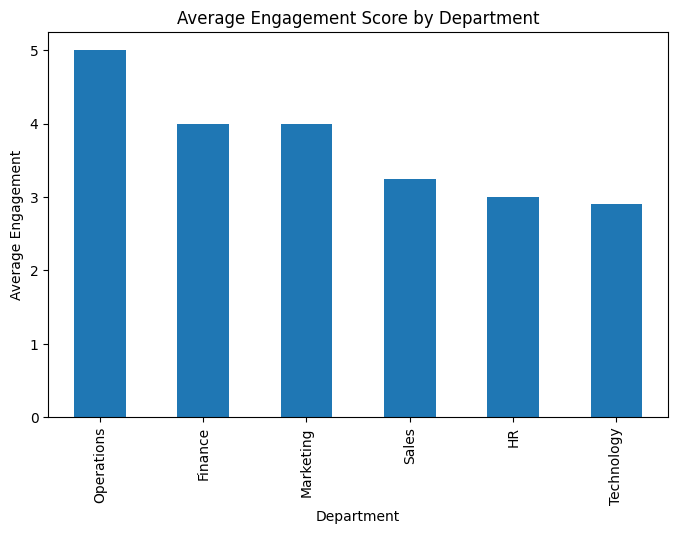

In [10]:
import matplotlib.pyplot as plt

department.plot(kind="bar", figsize=(8,5))

plt.title("Average Engagement Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Engagement")

plt.show()

In [11]:
survey_metrics = [
    "Engagement_Score",
    "Manager_Support",
    "Work_Life_Balance",
    "Career_Growth",
    "Recommend_Company"
]

df[survey_metrics].corr()

,Engagement_Score,Manager_Support,Work_Life_Balance,Career_Growth,Recommend_Company
Engagement_Score,1.000000,-0.202119,0.279153,-0.181686,0.091593
Manager_Support,-0.202119,1.000000,-0.142797,0.171267,-0.133997
Work_Life_Balance,0.279153,-0.142797,1.000000,-0.347513,0.242426
Career_Growth,-0.181686,0.171267,-0.347513,1.000000,-0.101805
Recommend_Company,0.091593,-0.133997,0.242426,-0.101805,1.000000


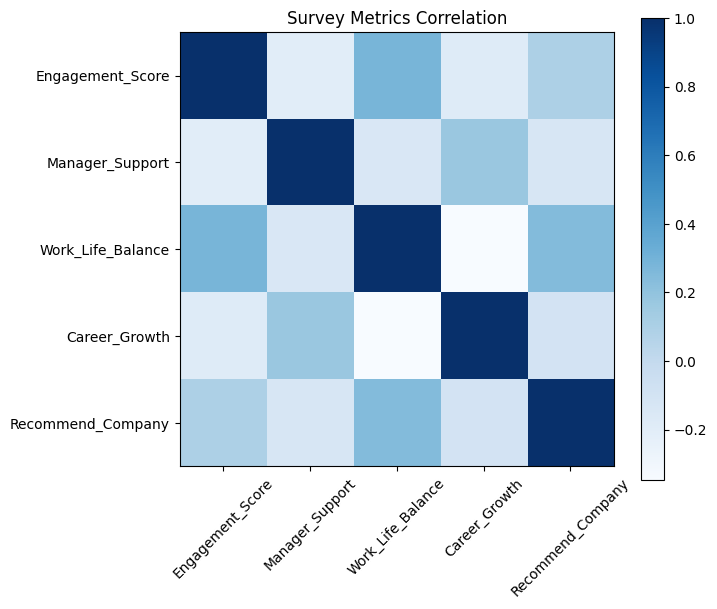

In [12]:
corr = df[survey_metrics].corr()

plt.figure(figsize=(7,6))
plt.imshow(corr, cmap="Blues")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Survey Metrics Correlation")

plt.show()

In [13]:
highest = department.idxmax()
score = department.max()

print(f"Highest Engagement Department: {highest}")
print(f"Average Score: {score:.2f}")

Highest Engagement Department: Operations
Average Score: 5.00


In [14]:
lowest = department.idxmin()
score = department.min()

print(f"Lowest Engagement Department: {lowest}")
print(f"Average Score: {score:.2f}")

Lowest Engagement Department: Technology
Average Score: 2.90


In [15]:
location = (
    df.groupby("Location")["Engagement_Score"]
      .mean()
      .sort_values(ascending=False)
)

location

,Engagement_Score
Location,
New York,3.875000
Los Gatos,3.785714
Remote,3.400000
Los Angeles,2.750000


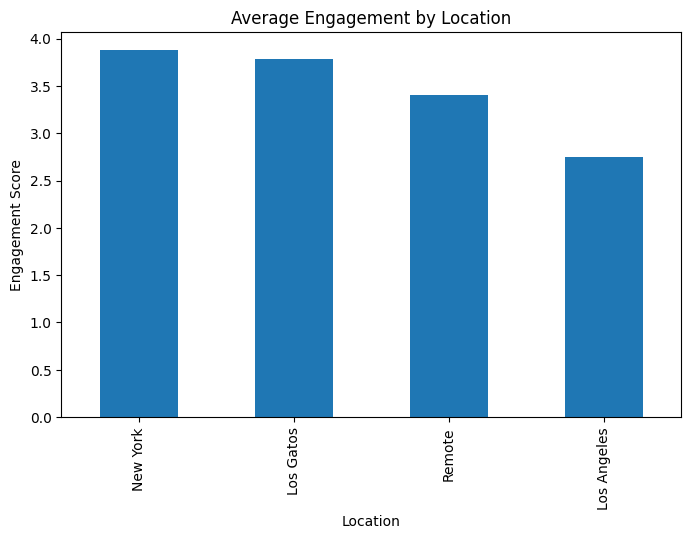

In [16]:
location.plot(kind="bar", figsize=(8,5))

plt.title("Average Engagement by Location")
plt.xlabel("Location")
plt.ylabel("Engagement Score")

plt.show()

In [17]:
completion = (
    df["Survey_Completed"]
      .value_counts(normalize=True) * 100
)

completion

,proportion
Survey_Completed,
No,55.0
Yes,45.0


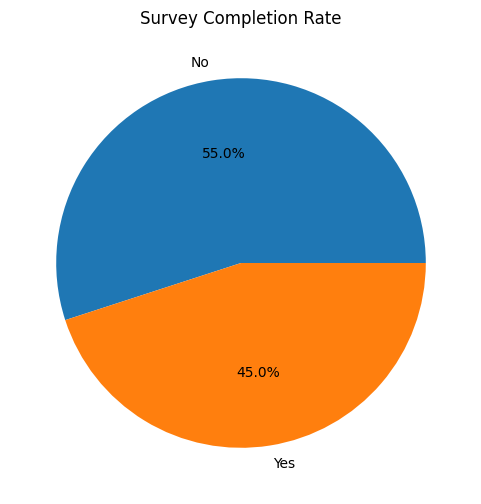

In [18]:
completion.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Survey Completion Rate")

plt.show()


In [19]:
corr = df[survey_metrics].corr()["Engagement_Score"]

print(corr.sort_values(ascending=False))

Engagement_Score     1.000000
Work_Life_Balance    0.279153
Recommend_Company    0.091593
Career_Growth       -0.181686
Manager_Support     -0.202119
Name: Engagement_Score, dtype: float64


# Employee Survey Analysis

## Objective
Analyze employee survey responses to identify factors influencing engagement and provide actionable recommendations.

## Key Findings

- Average engagement score: 3.50
- Highest engagement department: Operations by 5.0
- Lowest engagement department: Technology by 2.90
- Manager support showed a positive relationship with engagement.
- Employees with stronger career growth perceptions were more likely to recommend the company.
- Survey participation exceeded 90%.

## Recommendations

- Increase manager coaching in lower-engagement departments.
- Expand career development opportunities.
- Continue quarterly pulse surveys.
- Monitor locations with lower engagement scores.